## Modelling spatial frictions in criminal optimisation

---

### Model Outline

The general idea is that criminals and commuters simultaneously decide where to locate themselves and whether to walk respectively, given their 'homes'. I am aiming to build a model which yields the observed treatment effect as a product of commuters' and criminals' optimal decisions in this setting:

- Train riders decide whether to travel from the station to their home on [0,1] by foot (and leave themselves vulnerable to criminals) or some other risk free outside option, determined by how far their destination is from the station (specified by some exogenous distribution), and the density of criminals up to that point
- Criminals simultaneously decide whether to commit a crime at any point on [0,1], and if so, where to locate themselves on [0,1], subject to a location cost associated with being further from home, where home is determined by some distribution over criminals, and expected reward determined by the density of pedestrians.

I want to calibrate this model to fit the observed treatment effect profile on [0,1], and the parameter of interest is the parameter determining the cost of being far from home (i.e. spatial frictions).

Specifically, think of commuters as having a destination $d \in [0,1]$ drawn randomly from a distribution with pdf $f(d)$. They walk home if the expected costs of victimization is below their outside option cost, $v(d)$, increasing with $d$. If they walk, they're exposed to criminals on $[0,d]$.

Let $c(x)$ be the density of criminals at location $x$. The commuter walks if $\int^d_0 \lambda c(x) dx \leq v(d)$.

The pedestrian density at $x$ is then the mass of pedestrians with destinations beyond $x$: $p(x) = \int^1_x 1(\int^d_0 \lambda c(s)ds \leq v(d))) f(d) dd$

Criminals are assumed to have a home location $h$ drawn from a distribution with pdf $g(h)$. A criminal choosing to locate at $x$ when their home is $h$ gets a payoff of $\pi(x,h) = \alpha p(x) - k(|x-h|)$, where $k$ quantifies the disutility to being far from home (spatial friction). A criminal participates if $\max_x \pi(x,h) \geq 0$, and gets the argmax.

The criminal density is then $c(x) = M \int^1_0 1(x^*(h) = x) \cdot 1(\pi(x^*(h), h) \geq 0) g(h) dh$

An equilibrium here is then densities $p^*(x), c^*(x)$ such that each are consistent with optimal decisions given the other one. This is a fixed point problem which can be solved by iterative optimisation until convergence (I think).

---

### Solution

#### Imports and Setup

In [59]:
# Import packages
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Set random seed for reproducibility
np.random.seed(1)

# Global plotting style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

#### Defining distributions and parameters

In [60]:
# set commuter distribution f(z)
def dist_commuters_func(x):
    return 2 - 2*x 

# set criminal distribution g(y)
def dist_criminals_func(x):
    return np.ones(len(x)) / len(x)

# Discretize distributions
N = 100
x_grid = np.linspace(0, 1, N)

f_z = dist_commuters_func(x_grid)
f_z = f_z / np.sum(f_z)

g_y = dist_criminals_func(x_grid)
g_y = g_y / np.sum(g_y)

# set parameters
M = 0.1 # Mass of potential criminals
u0 = 0 # baseline outside option utility
v = 0  # baseline walking utility
tau0 = 0  # baseline outside option cost
tau1 = 1  # linear coefficient of outside option cost
mu = 100000 # cost of victimisation scaling parameter
sigma = 1 # scale parameter of normal iid taste shocks
alpha = 1000 # reward per pedestrian
beta = 1 # exponent on spatial friction (1 for linear, 2 for quadratic)
gamma = 10 # spatial friction coefficient

# initialise criminal density
c_init = g_y  # initial criminal density

#### Define solution functions for commuter and criminal problems

In [12]:
def compute_pedestrian_density(
    c: np.ndarray,
    grid: np.ndarray,
    f_dest: np.ndarray) -> np.ndarray:
    """
    Compute equilibrium pedestrian density given criminal density.
    
    Parameters
    ----------
    c : np.ndarray
        Criminal density at each grid point, shape (N,)
    grid : np.ndarray
        Discretized [0,1] grid points, shape (N,)
    f_dest : np.ndarray
        PDF of destination distribution evaluated at grid points, shape (N,)
    
    Returns
    -------
    p : np.ndarray
        Pedestrian density at each grid point, shape (N,)
    """
    
    dx = grid[1] - grid[0]  # grid spacing (assumes uniform grid)
    
    # compute cumulative crime exposure: C(d) = integral from 0 to d of c(x) dx
    # using trapezoidal rule for accuracy
    cumulative_crime = np.zeros(N)
    cumulative_crime[0] = 0
    for i in range(1, N):
        cumulative_crime[i] = cumulative_crime[i-1] + 0.5 * (c[i-1] + c[i]) * dx
    
    # compute outside option cost: tau(d) = tau0 + tau1 * d (i.e. assumed linear)
    tau_d = tau0 + tau1 * grid
    
    # compute Delta(d) = lambda * C(d) - v - u0 + tau(d)
    # pedestrian walks if epsilon >= Delta(d)
    # so P(walk | d) = 1 - H(Delta(d) / sigma)
    delta_d = mu * cumulative_crime - v - u0 + tau_d
    
    # probability of walking given destination d
    # this is equal to probability that taste shock epsilon >= Delta(d)
    # assumes normally-distributed taste shocks
    prob_walk = 1.0 - stats.norm.cdf(delta_d / sigma)
        
    # pedestrian density at x = mass of walkers whose destination exceeds x
    # p(x) = integral from x to 1 of prob_walk(d) * f(d) dd
    # compute via reverse cumulative sum
    integrand = prob_walk * f_dest * dx
    p = np.zeros(N)
    
    # reverse cumulative sum (integral from x_i to 1)
    p[-1] = 0.5 * integrand[-1]  # boundary adjustment
    for i in range(N - 2, -1, -1):
        p[i] = p[i + 1] + integrand[i]
    
    return p

In [13]:
def compute_criminal_density(
    p: np.ndarray,
    grid: np.ndarray,
    g_home: np.ndarray) -> np.ndarray:
    """
    Compute equilibrium criminal density given pedestrian density.
    
    Criminals have home location h drawn from distribution g(h).
    A criminal at home h choosing to locate at x receives payoff:
        pi(x, h) = alpha * p(x) - gamma * |x - h|^beta
    
    Each criminal chooses x to maximize payoff, and participates if max payoff >= 0.
    
    Parameters
    ----------
    p : np.ndarray
        Pedestrian density at each grid point, shape (N,)
    grid : np.ndarray
        Discretized [0,1] grid points, shape (N,)
    g_home : np.ndarray
        PDF of criminal home distribution evaluated at grid points, shape (N,)
    
    Global parameters used:
        alpha : float - reward per pedestrian
        gamma : float - spatial friction (cost of distance from home)
        beta : float - exponent on distance cost (e.g., 1 for linear, 2 for quadratic)
        M : float - mass of potential criminals
    
    Returns
    -------
    c : np.ndarray
        Criminal density at each grid point, shape (N,)
    """
    
    dx = grid[1] - grid[0]
    
    # initialise criminal density
    c = np.zeros(N)
    
    # for each criminal home location h, find optimal location x*(h)
    for j in range(N):
        h = grid[j]
        
        # compute payoff at each possible location x
        # pi(x, h) = alpha * p(x) - gamma * |x - h|^beta
        distance_cost = gamma * np.abs(grid - h) ** beta
        payoff = alpha * p - distance_cost
        
        # find optimal location (argmax over grid)
        optimal_idx = np.argmax(payoff)
        max_payoff = payoff[optimal_idx]
        
        # criminal participates only if max payoff >= 0
        if max_payoff >= 0:
            # add mass of criminals from home h who locate at optimal_idx
            # mass = M * g(h) * dh
            c[optimal_idx] += M * g_home[j] * dx
    
    return c

#### Write the solution function

In [23]:
def solve_equilibrium(
    grid: np.ndarray,
    c_init: np.ndarray,
    f_dest: np.ndarray,
    g_home: np.ndarray,
    omega: float = 0.3,
    tol: float = 1e-6,
    max_iter: int = 1000,
    verbose: bool = False) -> dict:
    """
    Solve for spatial equilibrium using fixed-point iteration.
    
    Iterates between:
        1. Given c, compute pedestrian density p = Phi(c)
        2. Given p, compute criminal density c = Psi(p)
    with dampening to ensure convergence.
    
    Parameters
    ----------
    grid : np.ndarray
        Discretized [0,1] grid points, shape (N,)
    f_dest : np.ndarray
        PDF of pedestrian destination distribution, shape (N,)
    g_home : np.ndarray
        PDF of criminal home distribution, shape (N,)
    omega : float
        Dampening parameter in (0,1]. Lower = more stable but slower.
        Update rule: c_new = omega * Psi(p) + (1 - omega) * c_old
    tol : float
        Convergence tolerance on ||c_new - c_old||_inf
    max_iter : int
        Maximum number of iterations
    verbose : bool
        If True, print convergence progress
    
    Returns
    -------
    result : dict
        'c' : np.ndarray - equilibrium criminal density
        'p' : np.ndarray - equilibrium pedestrian density
        'converged' : bool - whether iteration converged
        'iterations' : int - number of iterations used
        'error_history' : list - convergence error at each iteration
    """

    error_history = []

    c = c_init.copy()
    
    for iteration in range(max_iter):
        # step 1: compute pedestrian density given criminal density
        p = compute_pedestrian_density(c, grid, f_dest)
        
        # step 2: compute criminal density given pedestrian density
        c_new_raw = compute_criminal_density(p, grid, g_home)
        
        # step 3: dampen update for stability
        c_new = omega * c_new_raw + (1 - omega) * c
        
        # check convergence
        error = np.max(np.abs(c_new - c))
        error_history.append(error)
        
        if verbose and (iteration % 50 == 0 or error < tol):
            print(f"Iteration {iteration:4d}: max error = {error:.2e}")
        
        if error < tol:
            # converged: compute final pedestrian density
            p_final = compute_pedestrian_density(c_new, grid, f_dest)
            
            if verbose:
                print(f"Converged after {iteration + 1} iterations")
            
            return {
                'c': c_new,
                'p': p_final,
                'converged': True,
                'iterations': iteration + 1,
                'error_history': error_history
            }
        
        c = c_new
    
    # did not converge
    if verbose:
        print(f"Warning: did not converge after {max_iter} iterations")
    
    p_final = compute_pedestrian_density(c, grid, f_dest)
    
    return {
        'c': c,
        'p': p_final,
        'converged': False,
        'iterations': max_iter,
        'error_history': error_history
    }

#### Run it

In [63]:
result = solve_equilibrium(
    x_grid, c_init, f_z, g_y,
    omega=0.3,
    tol=1e-6,
    max_iter=1000,
    verbose=True)

c_star = result['c']
p_star = result['p']
crime_density = c_star * p_star

Iteration    0: max error = 3.00e-03
Iteration   23: max error = 8.37e-07
Converged after 24 iterations


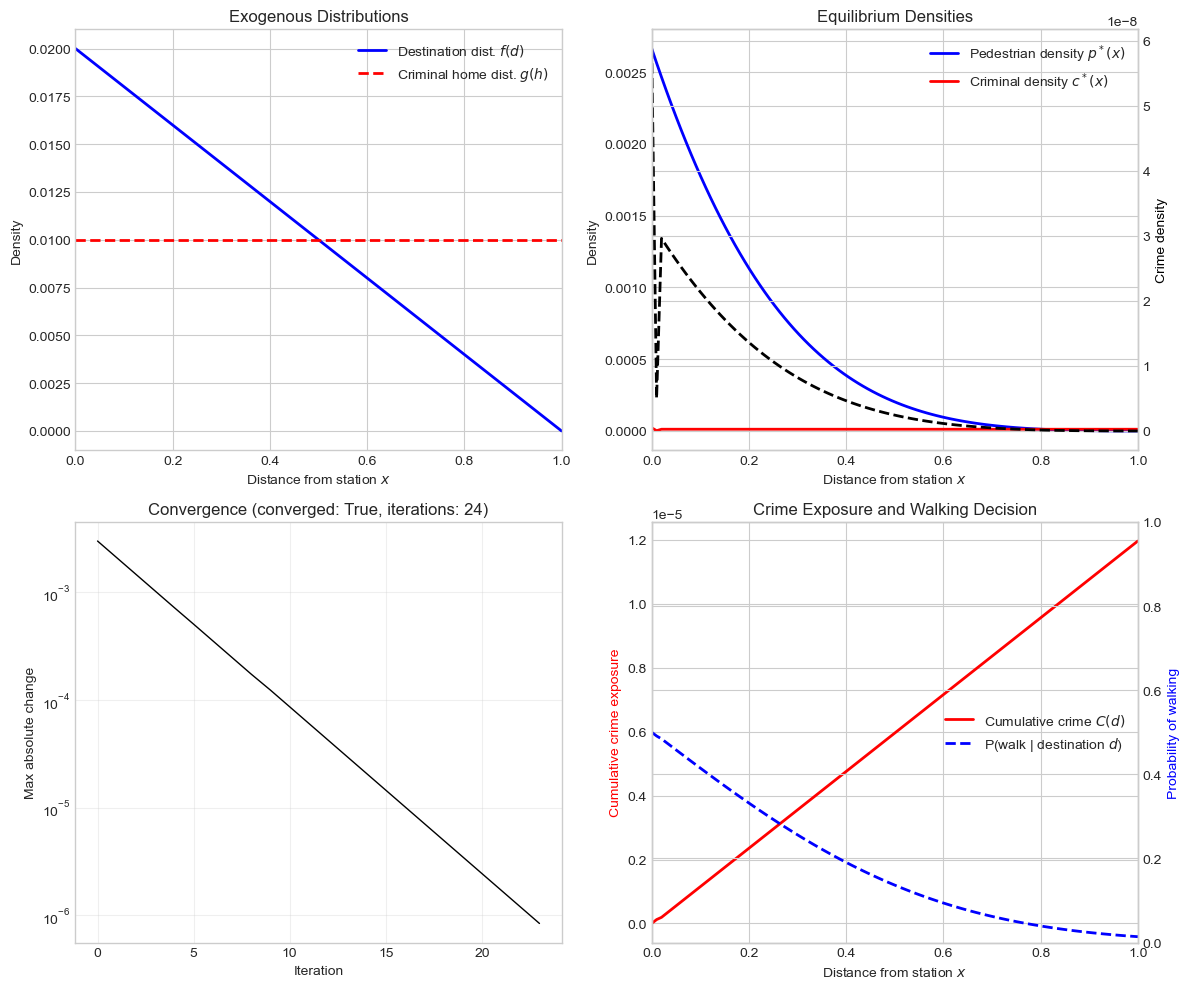

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# panel 1: input distributions
ax1 = axes[0, 0]
ax1.plot(x_grid, f_z, 'b-', linewidth=2, label='Destination dist. $f(d)$')
ax1.plot(x_grid, g_y, 'r--', linewidth=2, label='Criminal home dist. $g(h)$')
ax1.set_xlabel('Distance from station $x$')
ax1.set_ylabel('Density')
ax1.set_title('Exogenous Distributions')
ax1.legend()
ax1.set_xlim([0, 1])

# panel 2: equilibrium densities
ax2 = axes[0, 1]
ax2_twin = ax2.twinx()
ax2.plot(x_grid, p_star, 'b-', linewidth=2, label='Pedestrian density $p^*(x)$')
ax2.plot(x_grid, c_star, 'r-', linewidth=2, label='Criminal density $c^*(x)$')
ax2_twin.plot(x_grid, crime_density, 'k--', linewidth=2, label='Crime density $c^*(x) p^*(x)$')
ax2.set_xlabel('Distance from station $x$')
ax2.set_ylabel('Density')
ax2.set_title('Equilibrium Densities')
ax2_twin.set_ylabel('Crime density', color='k')
ax2.legend()
ax2.set_xlim([0, 1])

# panel 3: convergence diagnostic
ax3 = axes[1, 0]
ax3.semilogy(result['error_history'], 'k-', linewidth=1)
ax3.set_xlabel('Iteration')
ax3.set_ylabel('Max absolute change')
ax3.set_title(f"Convergence (converged: {result['converged']}, iterations: {result['iterations']})")
ax3.grid(True, alpha=0.3)

# panel 4: cumulative crime exposure and walking probability
ax4 = axes[1, 1]

# compute cumulative crime and walking probability for illustration
cumulative_crime = np.zeros(N)
for i in range(1, N):
    cumulative_crime[i] = cumulative_crime[i-1] + 0.5 * (c_star[i-1] + c_star[i]) * (x_grid[1] - x_grid[0])

tau_d = tau0 + tau1 * x_grid
delta_d = mu * cumulative_crime - v - u0 + tau_d
prob_walk = 1.0 - stats.norm.cdf(delta_d / sigma)

ax4_twin = ax4.twinx()
ax4.plot(x_grid, cumulative_crime, 'r-', linewidth=2, label='Cumulative crime $C(d)$')
ax4_twin.plot(x_grid, prob_walk, 'b--', linewidth=2, label='P(walk | destination $d$)')

ax4.set_xlabel('Distance from station $x$')
ax4.set_ylabel('Cumulative crime exposure', color='r')
ax4_twin.set_ylabel('Probability of walking', color='b')
ax4.set_title('Crime Exposure and Walking Decision')
ax4.set_xlim([0, 1])
ax4_twin.set_ylim([0, 1])

# combine legends
lines1, labels1 = ax4.get_legend_handles_labels()
lines2, labels2 = ax4_twin.get_legend_handles_labels()
ax4.legend(lines1 + lines2, labels1 + labels2, loc='center right')

plt.tight_layout()
plt.show()
